# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Check datatype

In [5]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [6]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [7]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [8]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [9]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')


In [10]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [11]:
df.shape[0]

891

In [12]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [13]:
median_1 = df['Age'].median()
df['Age'] = df['Age'].fillna(median_1, inplace=True)


In [14]:
df.dropna(subset=['Embarked'], inplace= True)


In [15]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,687.00000,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.27784,0.0


In [16]:
#pip install matplotlib 
#pip install seaborn  
#pip install plotly

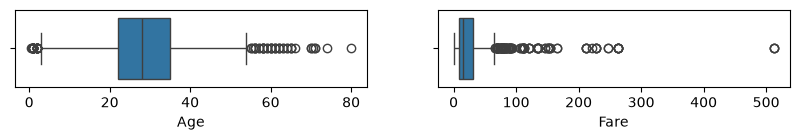

In [17]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(10,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    



In [18]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



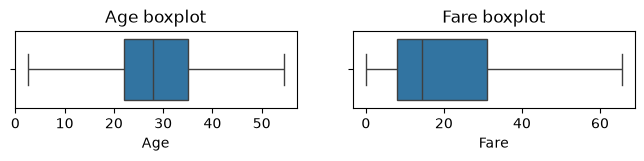

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} boxplot")



In [20]:
df.duplicated().sum()

np.int64(116)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
# df remove_duplicate(df, subset_cols= None,keep_stratgy = "first"):
    
#     return (df.drop_duplicates(subset=subset_cols, keep=keep_stratgy).reset_index(drop = True))

In [24]:
num_cols

Index(['Age', 'Fare'], dtype='str')

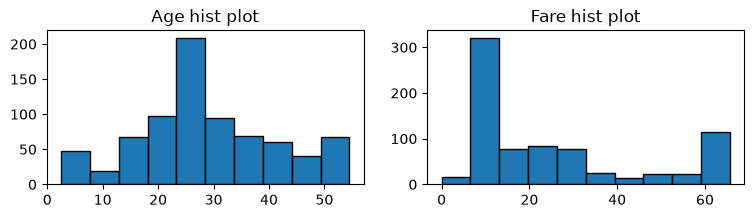

In [25]:
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    plt.hist(df[col] ,  edgecolor = "black")
    plt.title(f"{col} hist plot")
plt.show()    


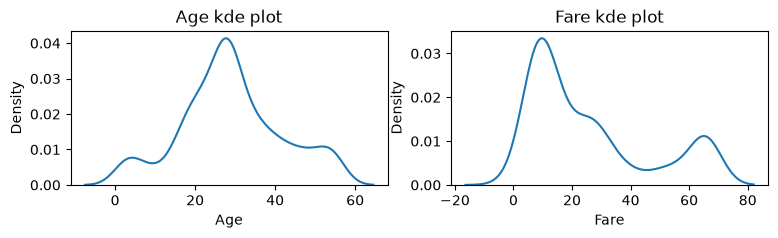

In [26]:
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} kde plot")
plt.show()    


## Categorical Data distribution

In [27]:
cat_cols= df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

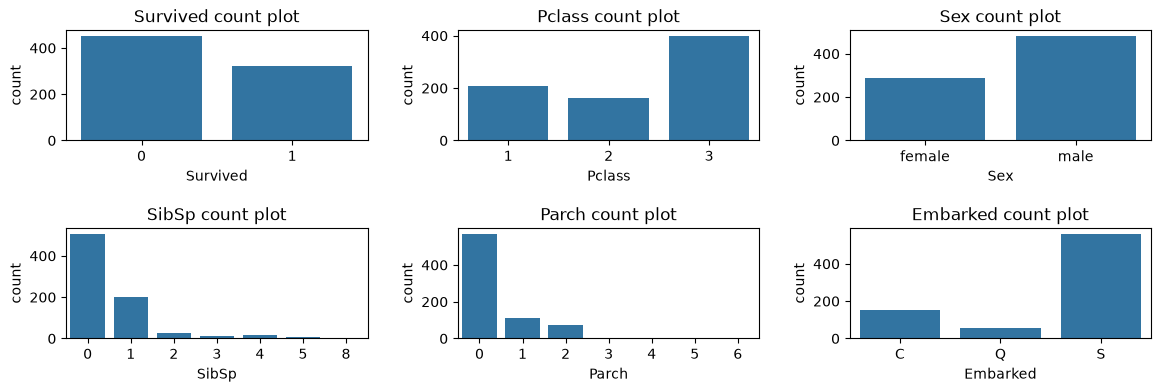

In [28]:
plt.figure(figsize=(14,4))
for i , cols in enumerate(cat_cols):
    plt.subplot(2,3 , i+1)
    sns.countplot(x = cols , data=df)
    plt.title(f"{cols} count plot")
plt.subplots_adjust(hspace= .8 ,  wspace=.3)    

In [29]:
unique = df["Survived"].value_counts()
print(unique)
count = unique.values
categories = unique.index

Survived
0    453
1    320
Name: count, dtype: int64


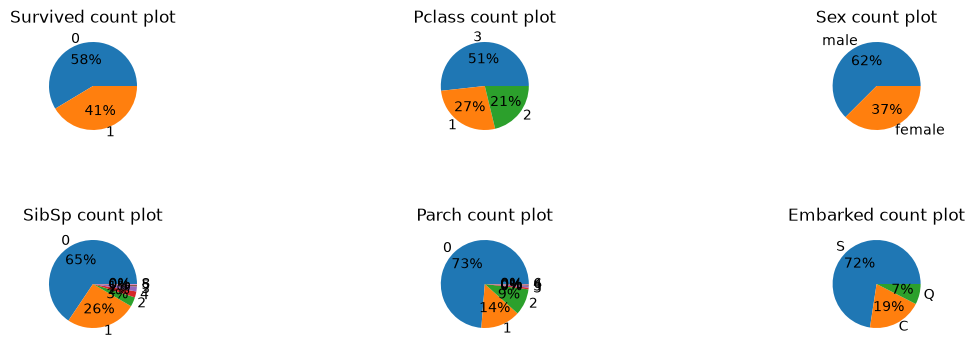

In [30]:
plt.figure(figsize=(14,4))
for i , cols in enumerate(cat_cols):
    plt.subplot(2,3 , i+1)
    unique = df[cols].value_counts()
    count = unique.values
    categories = unique.index
    plt.title(f"{cols} count plot")
    plt.pie(count ,  labels=categories , autopct= '%1.1d%%')
plt.subplots_adjust(hspace= .8 ,  wspace=.3)        

In [31]:
import plotly.express as px
fig = px.pie(df , names =  "Survived",
        title="<b> Survived pie plot",
        color_discrete_sequence=px.colors.qualitative.Pastel,
        hole=.4 )
fig.update_layout(annotations =  [dict(text= "Survived" ,  font_size  =20 , x = .5, y =.5 , showarrow = False)])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
              'hole': 0.4,
              'hovertemplate': 'Survived=%{label}<extra></extra>',
              'labels': {'bdata': ('AAEBAQAAAAABAQEBAAAAAQABAAEAAQ' ... 'EAAQEAAQEAAAEBAAEBAAAAAAEAAQA='),
                         'dtype': 'i1'},
              'legendgroup': '',
              'name': '',
              'showlegend': True,
              'type': 'pie'}],
    'layout': {'annotations': [{'font': {'size': 20}, 'showarrow': False, 'text': 'Survived', 'x': 0.5, 'y': 0.5}],
               'legend': {'tracegroupgap': 0},
               'piecolorway': [rgb(102, 197, 204), rgb(246, 207, 113), rgb(248,
                               156, 116), rgb(220, 176, 242), rgb(135, 197, 95),
                               rgb(158, 185, 243), rgb(254, 136, 177), rgb(201,
                               219, 116), rgb(139, 224, 164), rgb(180, 151, 231),
                               rgb(179, 179, 179)],
               'template': '...',
               'title': {'text': '<b> Survived pie plot'}}
})

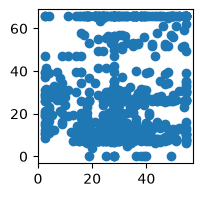

In [32]:
plt.figure(figsize=(2,2))
plt.scatter(df["Age"] , df["Fare"])

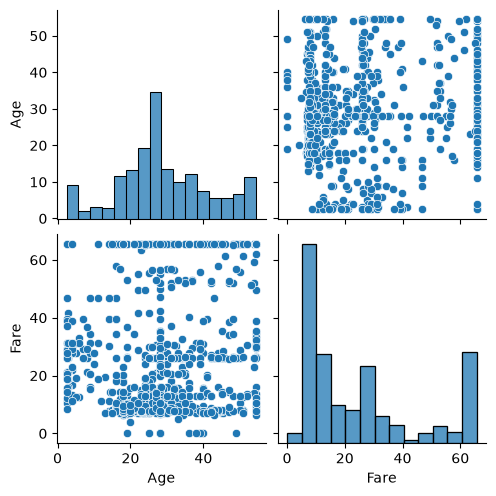

In [33]:
sns.pairplot(df)

<Axes: >

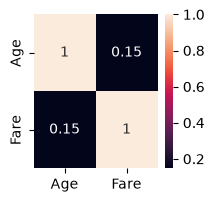

In [34]:
corr = df[num_cols].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr , annot= True)


In [35]:
x =  df.drop("Survived" ,axis= 1)
y = df["Survived"]

In [36]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,65.6563,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
885,3,female,39.0,0,5,29.1250,NaN,Q
887,1,female,19.0,0,0,30.0000,B42,S
888,3,female,28.0,1,2,23.4500,NaN,S
889,1,male,26.0,0,0,30.0000,C148,C


In [37]:
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 773, dtype: category
Categories (2, int64): [0, 1]

In [38]:
from sklearn.preprocessing import MinMaxScaler
num_cols =  x.select_dtypes('number').columns
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.fit_transform(x[num_cols])

In [39]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,0.375000,1,0,0.110424,NaN,S
1,1,female,0.682692,1,0,1.000000,C85,C
2,3,female,0.451923,0,0,0.120704,NaN,S
3,1,female,0.625000,1,0,0.808757,C123,S
4,3,male,0.625000,0,0,0.122608,NaN,S
...,...,...,...,...,...,...,...,...
885,3,female,0.701923,0,5,0.443598,NaN,Q
887,1,female,0.317308,0,0,0.456925,B42,S
888,3,female,0.490385,1,2,0.357163,NaN,S
889,1,male,0.451923,0,0,0.456925,C148,C


In [ ]:
nominal , ordinal
nominal no priority the same cardinaliti

ordinal -> something like amonts typed in string way

In [40]:
from category_encoders import OneHotEncoder
str_cols = ['Embarked','Sex']
encoder = OneHotEncoder(cols = str_cols,drop_invariant=True)
x=encoder.fit_transform(x)

In [41]:
x

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Cabin,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.375000,1,0,0.110424,NaN,1,0,0
1,1,0,1,0.682692,1,0,1.000000,C85,0,1,0
2,3,0,1,0.451923,0,0,0.120704,NaN,1,0,0
3,1,0,1,0.625000,1,0,0.808757,C123,1,0,0
4,3,1,0,0.625000,0,0,0.122608,NaN,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
885,3,0,1,0.701923,0,5,0.443598,NaN,0,0,1
887,1,0,1,0.317308,0,0,0.456925,B42,1,0,0
888,3,0,1,0.490385,1,2,0.357163,NaN,1,0,0
889,1,1,0,0.451923,0,0,0.456925,C148,0,1,0
